# Exercise 1 — Tabular Classification
### Rice Type Classifier

---

## The Problem

A rice processing company receives mixed batches of two rice varieties —
**Cammeo** and **Osmancik** — and needs to sort them automatically
using physical measurements taken by a camera system.# Exercise 1 — Tabular Classification

You are the ML engineer. Given a dataset of grain measurements,
build a classifier that identifies the rice type.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")
```

A CSV file with physical measurements of individual rice grains:
area, perimeter, axis lengths, eccentricity, convex area, and more.
The target column is `Class`.

⚠️ **One thing worth knowing:** the raw feature values are on very different
scales. A model trained on un-normalized data will struggle.
How you handle that is up to you.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained PyTorch model** that classifies rice type from grain measurements
2. **A training report** — loss and accuracy curves over epochs for both
   training and validation sets
3. **A test accuracy score** — your final number on held-out data
4. **A live inference demo** — given a set of raw measurements,
   the model outputs the predicted rice type

Your model must be built in **PyTorch** (`nn.Module`, training loop, DataLoader).
No sklearn classifiers.

---

In [67]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import kagglehub
from typing import Tuple, Dict,List
from torch.utils.data import TensorDataset, DataLoader



dataset_name = "mssmartypants/rice-type-classification"
target_col = 'Class'
test_size = 0.15
val_size = 0.15
random_state = 42

learning_rate = 1e-3 
batch_size = 64
num_workers = 2 
hidden_dim = 64      # Number of neurons in the hidden layer
dropout_rate = 0.2  

earning_rate = 1e-3 # 0.001
num_epochs = 50      # How many times to loop through the training data
weight_decay = 1e-5 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {DEVICE}")

🚀 Using device: cuda


In [27]:
def download_kaggle_dataset(dataset_name: str) -> str:

  print(f"Downloading dataset '{dataset_name}' using kagglehub...")
  path = kagglehub.dataset_download(dataset_name)
  print(f"✅ Dataset available at: {path}")
  return path

dataset_path = download_kaggle_dataset(dataset_name)
!cd {dataset_path} && ls -l

Using Colab cache for faster access to the 'rice-type-classification' dataset.
✅ Dataset available at: /kaggle/input/rice-type-classification
total 1984
-rw-r--r-- 1 1000 1000 2027644 Jun 14 10:21 riceClassification.csv


In [32]:
df = pd.read_csv(Path(dataset_path) / "riceClassification.csv")
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

Dataset loaded successfully! Shape: (18185, 12)


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


# EDA AND preprocessing

In [ ]:
def perform_eda(df: pd.DataFrame) -> None:
    print("="*50)
    print("1. DATASET SHAPE & INFO")
    print("="*50)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
    print(df.info())
    
    print("\n" + "="*50)
    print("2. MISSING VALUES CHECK")
    print("="*50)
    missing_values = df.isnull().sum()
    if missing_values.sum() == 0:
        print("✅ No missing values found. Data is clean!")
    else:
        print("⚠️ Missing values found:\n", missing_values[missing_values > 0])
        
    print("\n" + "="*50)
    print("3. CLASS DISTRIBUTION (Target Variable)")
    print("="*50)
    target_col = 'Class'
    if target_col in df.columns:
        class_counts = df[target_col].value_counts()
        print(class_counts)
        print(f"\nClass Ratio: {class_counts.max() / class_counts.min():.2f} : 1")
    else:
        print(f"⚠️ Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")
        
    print("\n" + "="*50)
    print("4. FEATURE STATISTICS (First 5 columns)")
    print("="*50)
    display(df.describe().iloc[:, :5])

# Execute the EDA on our loaded dataset
perform_eda(df)

1. DATASET SHAPE & INFO
Rows: 18185, Columns: 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB
None

2. MISSING VALUES CHECK
✅ No missing values found. Data is clean!

3. CLASS DISTRIBUTION (Target Variable)
Class
1    9985
0    8200
Name: co

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,9093.000000,7036.492989,151.680754,59.807851,0.915406
std,5249.701658,1467.197150,12.376402,10.061653,0.030575
min,1.000000,2522.000000,74.133114,34.409894,0.676647
25%,4547.000000,5962.000000,145.675910,51.393151,0.891617
50%,9093.000000,6660.000000,153.883750,55.724288,0.923259
75%,13639.000000,8423.000000,160.056214,70.156593,0.941372
max,18185.000000,10210.000000,183.211434,82.550762,0.966774


In [38]:
def prepare_data_for_eda(df: pd.DataFrame, id_column: str = 'id') -> pd.DataFrame:
    if id_column in df.columns:
        print(f"🗑️ Dropping '{id_column}' column...")
        return df.drop(columns=[id_column])
    return df

df_rice_clean = prepare_data_for_eda(df)

🗑️ Dropping 'id' column...


In [ ]:
def plot_correlation_matrix(df: pd.DataFrame, figsize: tuple = (12, 9)) -> None:
    """
    Plots a heatmap of the correlation matrix for all numerical features.
    
    Args:
        df (pd.DataFrame): The cleaned dataset.
        figsize (tuple): The size of the matplotlib figure.
    """
    print("📊 Plotting Correlation Matrix...")
    plt.figure(figsize=figsize)
    
    # Calculate correlation (numeric_only=True ensures no errors if non-numeric cols exist)
    corr_matrix = df.corr(numeric_only=True)
    
    # Create heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_feature_distributions(df: pd.DataFrame) -> None:
 
    print("📊 Plotting Feature Distributions (Histograms)...")
    # Select only numerical columns (excluding the target 'Class' for cleaner plots)
    features = df.drop(columns=['Class']).select_dtypes(include=[np.number]).columns
    
    # Create subplots
    num_features = len(features)
    cols = 3
    rows = (num_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        sns.histplot(df[col], ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(col)
        
    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle("Feature Distributions", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_class_balance(df: pd.DataFrame, target_col: str = 'Class') -> None:
    """
    Plots a bar chart to visualize the balance of the target classes.
    
    Args:
        df (pd.DataFrame): The cleaned dataset.
        target_col (str): The name of the target column.
    """
    print("📊 Plotting Class Balance...")
    plt.figure(figsize=(8, 6))
    
    # Count the occurrences of each class
    class_counts = df[target_col].value_counts().sort_index()
    
    # Create the bar plot
    ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='viridis')
    
    # Add counts on top of the bars
    for i, count in enumerate(class_counts.values):
        ax.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
        
    plt.title(f'Distribution of Target Classes ({target_col})', fontsize=14, fontweight='bold')
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    
    plt.tight_layout()
    plt.show()

📊 Plotting Correlation Matrix...


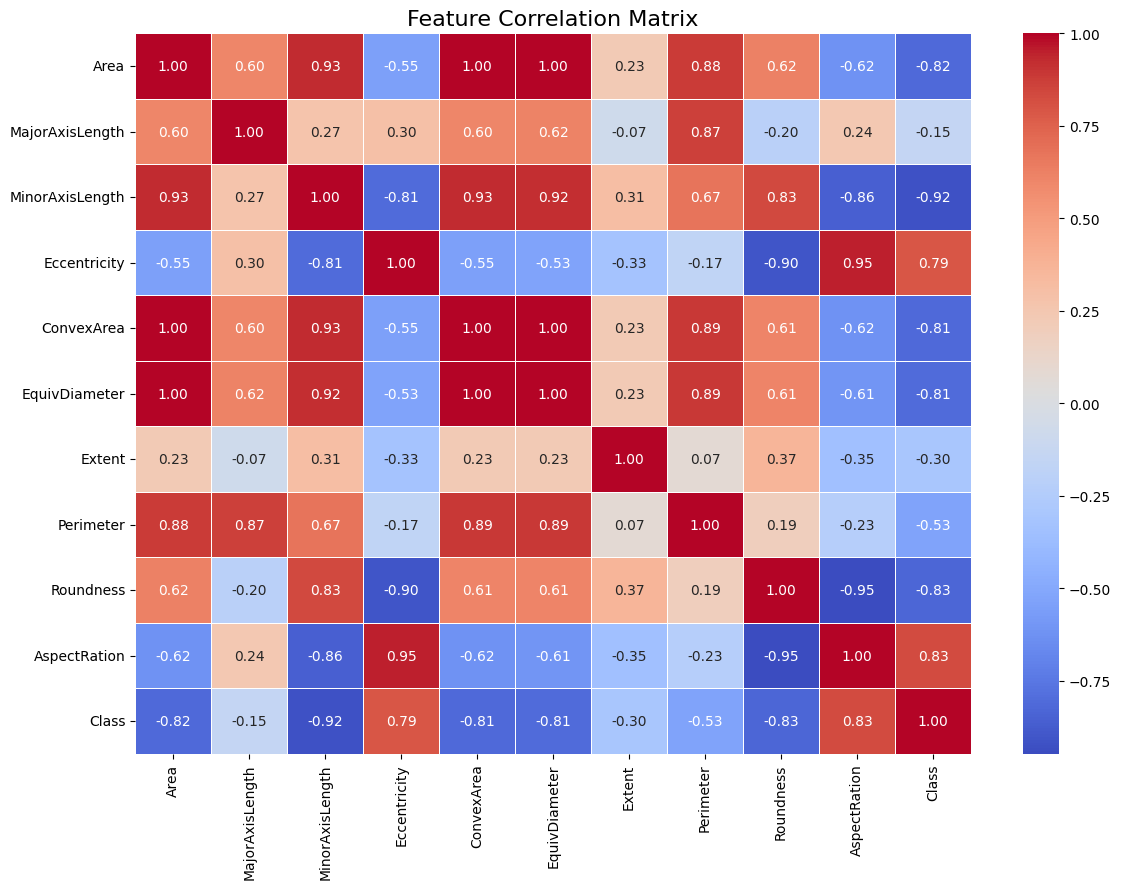

📊 Plotting Feature Distributions (Histograms)...


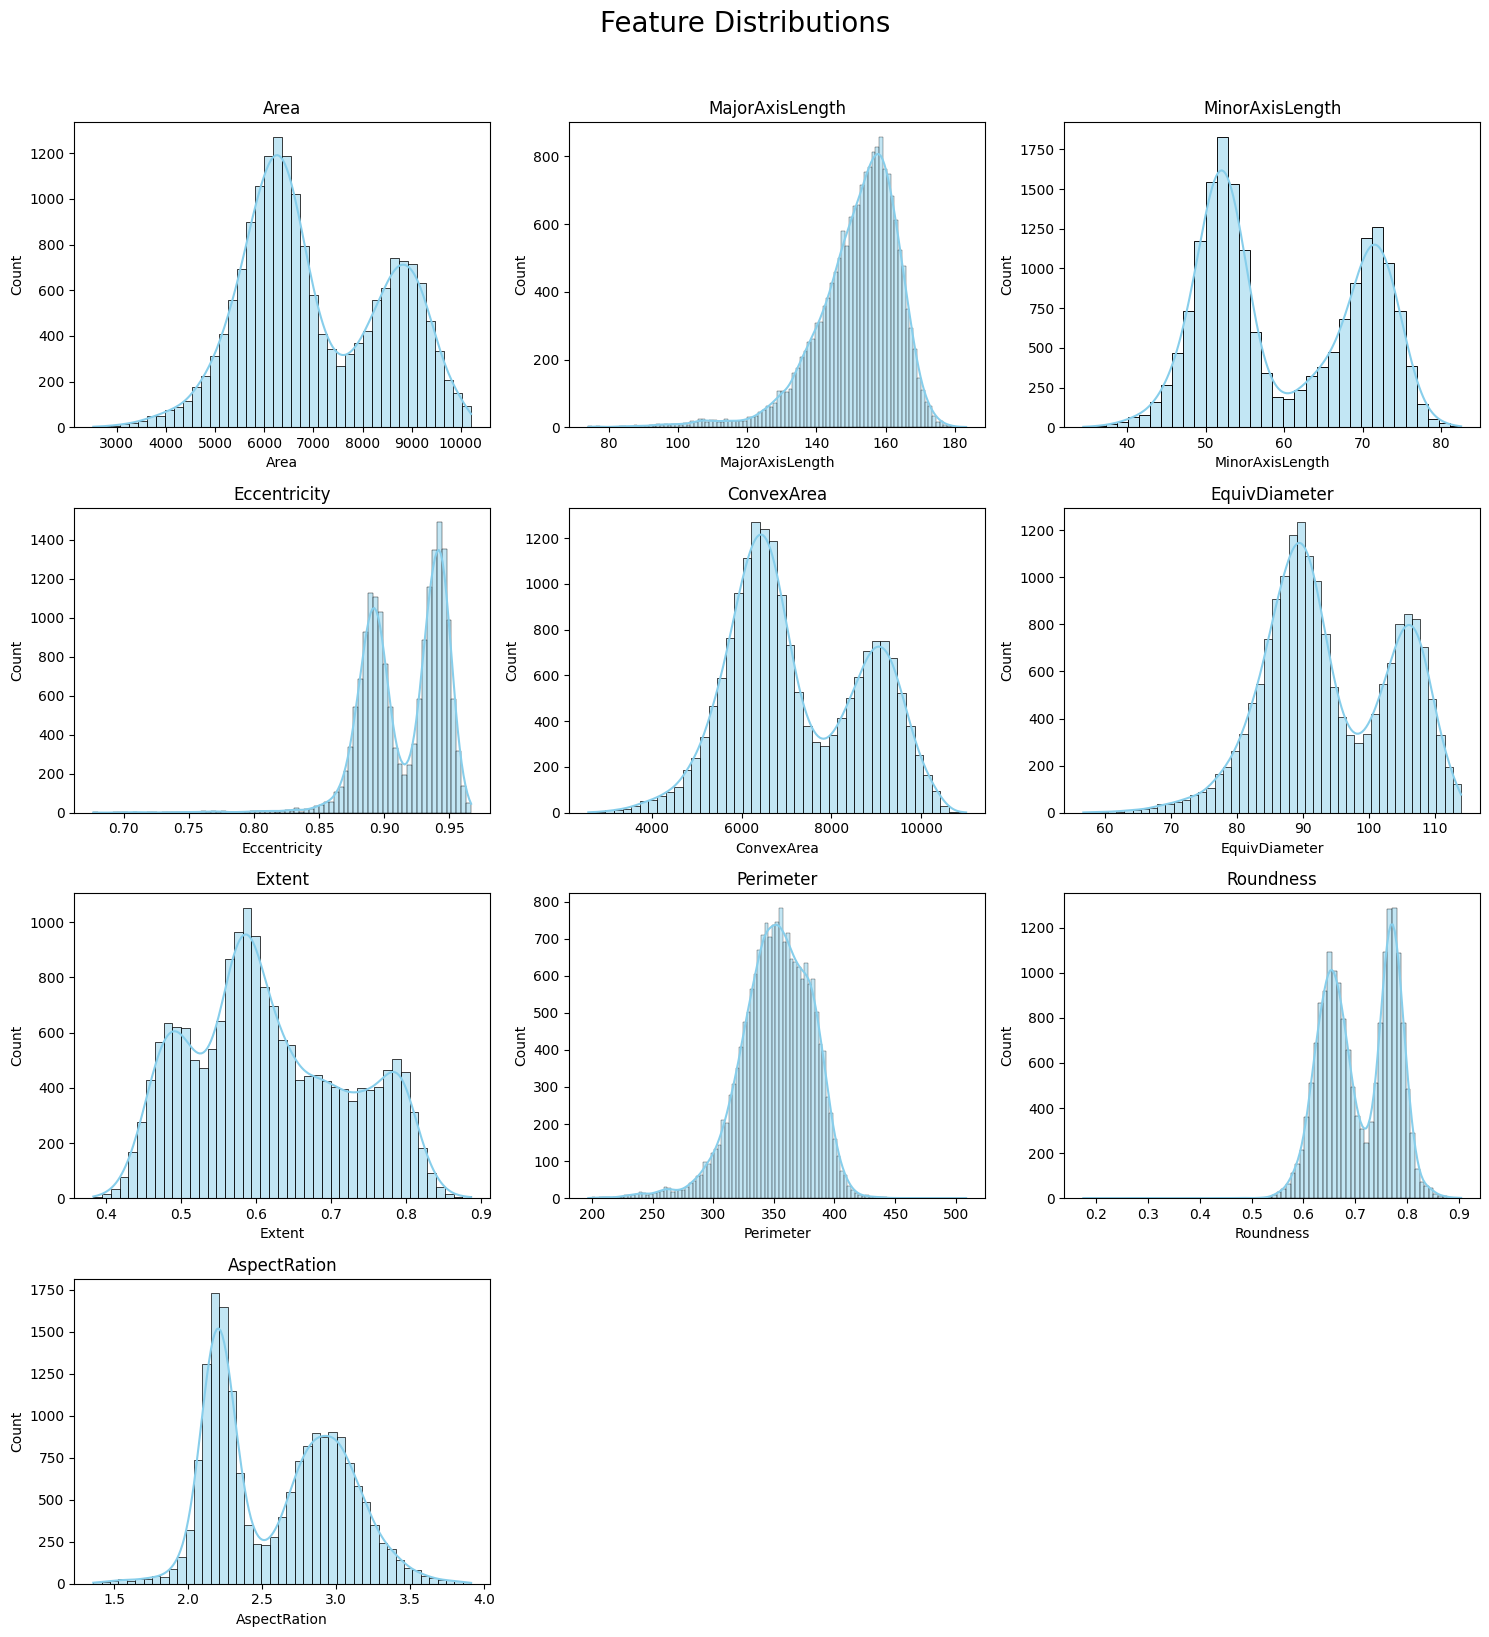

📊 Plotting Class Balance...


/tmp/ipykernel_2463/2504889205.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='viridis')


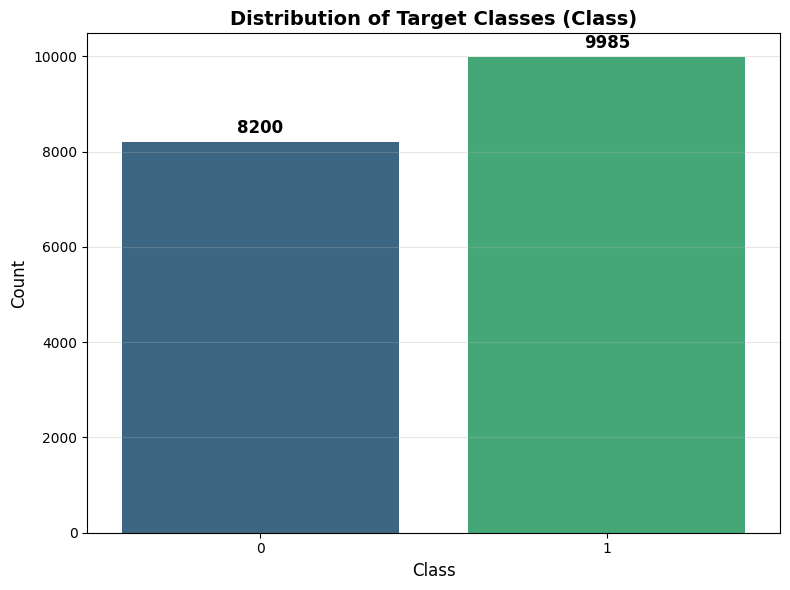

<Figure size 640x480 with 0 Axes>

In [46]:
# 1. Correlation Matrix
plot_correlation_matrix(df_rice_clean)

# 2. Feature Distributions
plot_feature_distributions(df_rice_clean)

# 3. Visualize Class Balance
plot_class_balance(df_rice_clean)



In [51]:
def prepare_datasets(df: pd.DataFrame, 
                     target_col: str = target_col,
                     test_size: float = test_size,
                     val_size: float = val_size,
                     random_state: int = random_state) -> Dict[str, np.ndarray]:

    # 1. Separate features and target
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    
    print(f"📊 Total samples: {len(X)} | Features shape: {X.shape}")
    
    # 2. First split: Isolate the Test set (15%)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        stratify=y,  
        random_state=random_state
    )
    
    # 3. Second split: Split the remaining data into Train and Val
    # Calculate the relative size for the validation set
    val_relative_size = val_size / (1.0 - test_size)
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_relative_size,
        stratify=y_train_val,  
        random_state=random_state
    )
    
    print(f"\n✅ Direct 3-way split completed:")
    print(f"   Training set:   {len(X_train):5d} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Validation set: {len(X_val):5d} samples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"   Test set:       {len(X_test):5d} samples ({len(X_test)/len(X)*100:.1f}%)")
    
    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }

def scale_features(data_dict: Dict[str, np.ndarray]) -> Tuple[Dict[str, np.ndarray], StandardScaler]:
    """
    Applies StandardScaler to features. Fits ONLY on training data to prevent data leakage.
    """
    print("\n⚖️  Scaling features with StandardScaler...")
    
    scaled_data = data_dict.copy()
    
    # Fit ONLY on training data
    scaler = StandardScaler()
    scaler.fit(data_dict['X_train'])
    
    # Transform all sets
    scaled_data['X_train'] = scaler.transform(data_dict['X_train'])
    scaled_data['X_val'] = scaler.transform(data_dict['X_val'])
    scaled_data['X_test'] = scaler.transform(data_dict['X_test'])
    
    print("✅ Scaling completed (fitted on training data only)")
    print(f"   Mean after scaling (train): {scaled_data['X_train'].mean():.6f}")
    print(f"   Std after scaling (train):  {scaled_data['X_train'].std():.6f}")
    
    return scaled_data, scaler

def convert_to_tensors(data_dict: Dict[str, np.ndarray], 
                       y_dict: Dict[str, np.ndarray]) -> Dict[str, torch.Tensor]:
    """
    Converts numpy arrays to PyTorch tensors.
    """
    print("\n🔄 Converting to PyTorch tensors...")
    
    tensors = {}
    for key in ['X_train', 'X_val', 'X_test']:
        tensors[key] = torch.FloatTensor(data_dict[key])
        
    for key in ['y_train', 'y_val', 'y_test']:
        tensors[key] = torch.LongTensor(y_dict[key])
    
    print("✅ Conversion completed:")
    print(f"   Features dtype: {tensors['X_train'].dtype}")
    print(f"   Labels dtype:   {tensors['y_train'].dtype}")
    
    return tensors

In [52]:
# Step 1: Direct 3-way split
data_splits = prepare_datasets(df_rice_clean, target_col='Class')

# Step 2: Scale the features
scaled_data, scaler = scale_features({
    'X_train': data_splits['X_train'],
    'X_val': data_splits['X_val'],
    'X_test': data_splits['X_test']
})

# Step 3: Convert to PyTorch tensors
tensors = convert_to_tensors(
    scaled_data,
    {
        'y_train': data_splits['y_train'],
        'y_val': data_splits['y_val'],
        'y_test': data_splits['y_test']
    }
)

# Verify the final shapes
print("\n" + "="*50)
print("FINAL TENSOR SHAPES")
print("="*50)
print(f"X_train: {tensors['X_train'].shape}, y_train: {tensors['y_train'].shape}")
print(f"X_val:   {tensors['X_val'].shape}, y_val:   {tensors['y_val'].shape}")
print(f"X_test:  {tensors['X_test'].shape}, y_test:  {tensors['y_test'].shape}")

📊 Total samples: 18185 | Features shape: (18185, 10)

✅ Direct 3-way split completed:
   Training set:   12729 samples (70.0%)
   Validation set:  2728 samples (15.0%)
   Test set:        2728 samples (15.0%)

⚖️  Scaling features with StandardScaler...
✅ Scaling completed (fitted on training data only)
   Mean after scaling (train): -0.000000
   Std after scaling (train):  1.000000

🔄 Converting to PyTorch tensors...
✅ Conversion completed:
   Features dtype: torch.float32
   Labels dtype:   torch.int64

FINAL TENSOR SHAPES
X_train: torch.Size([12729, 10]), y_train: torch.Size([12729])
X_val:   torch.Size([2728, 10]), y_val:   torch.Size([2728])
X_test:  torch.Size([2728, 10]), y_test:  torch.Size([2728])


In [57]:
def create_dataloaders(
    tensors: Dict[str, torch.Tensor], 
    batch_size: int, 
    num_workers: int
) -> Tuple[DataLoader, DataLoader, DataLoader]:

    print(" Creating PyTorch Datasets and DataLoaders...")
    
    # 1. Create TensorDatasets (wraps features and labels together)
    train_dataset = TensorDataset(tensors['X_train'], tensors['y_train'])
    val_dataset = TensorDataset(tensors['X_val'], tensors['y_val'])
    test_dataset = TensorDataset(tensors['X_test'], tensors['y_test'])
    
    # 2. Create DataLoaders
    # CRITICAL: shuffle=True for training, shuffle=False for val/test
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers
    )
    
    print("✅ DataLoaders created successfully!")
    return train_loader, val_loader, test_loader

# Execute the function using our tensors from Step 2 and config variables
train_loader, val_loader, test_loader = create_dataloaders(
    tensors=tensors, 
    batch_size=batch_size, 
    num_workers=num_workers
)

 Creating PyTorch Datasets and DataLoaders...
✅ DataLoaders created successfully!


In [58]:
def verify_dataloaders(
    train_loader: DataLoader, 
    val_loader: DataLoader, 
    test_loader: DataLoader
) -> None:
    """
    Prints the shape of the first batch from each DataLoader to verify correctness.
    """
    print("\n🔍 Verifying DataLoader batches...")
    
    for name, loader in [("Train", train_loader), ("Val", val_loader), ("Test", test_loader)]:
        # Get one batch
        X_batch, y_batch = next(iter(loader))
        
        print(f"  {name} Loader:")
        print(f"    - Batch X shape: {X_batch.shape} | dtype: {X_batch.dtype}")
        print(f"    - Batch y shape: {y_batch.shape} | dtype: {y_batch.dtype}")
        print(f"    - Total batches: {len(loader)}")

# Run verification
verify_dataloaders(train_loader, val_loader, test_loader)


🔍 Verifying DataLoader batches...
  Train Loader:
    - Batch X shape: torch.Size([64, 10]) | dtype: torch.float32
    - Batch y shape: torch.Size([64]) | dtype: torch.int64
    - Total batches: 199
  Val Loader:
    - Batch X shape: torch.Size([64, 10]) | dtype: torch.float32
    - Batch y shape: torch.Size([64]) | dtype: torch.int64
    - Total batches: 43
  Test Loader:
    - Batch X shape: torch.Size([64, 10]) | dtype: torch.float32
    - Batch y shape: torch.Size([64]) | dtype: torch.int64
    - Total batches: 43


#  Model Architecture

In [59]:
class RiceClassifier(nn.Module):
    """
    A simple Multi-Layer Perceptron (MLP) for tabular rice classification.
    Architecture: Input -> Linear -> ReLU -> Dropout -> Linear -> Output (Logits)
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout_rate: float) -> None:
        """
        Initializes the layers of the neural network.
        
        Args:
            input_dim (int): Number of input features (10).
            hidden_dim (int): Number of neurons in the hidden layer (64).
            output_dim (int): Number of output classes (2).
            dropout_rate (float): Probability of dropping a neuron (0.2).
        """
        super(RiceClassifier, self).__init__()
        
        # 1. Input to Hidden Layer
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        
        # 2. Activation Function (ReLU)
        self.relu = nn.ReLU()
        
        # 3. Regularization (Dropout)
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # 4. Hidden to Output Layer (Outputs raw logits, NO Softmax here!)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network.
        
        Args:
            x (torch.Tensor): Input batch of features.
            
        Returns:
            torch.Tensor: Raw logits for each class.
        """
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [60]:
def initialize_model(
    input_dim: int, 
    hidden_dim: int, 
    output_dim: int, 
    dropout_rate: float, 
    device: torch.device
) -> nn.Module:
 
    model = RiceClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        dropout_rate=dropout_rate
    )
    
    # Move model to GPU if available
    model = model.to(device)
    
    return model

# --- Configuration for Model Instantiation ---
INPUT_DIM = 10   # We have 10 features (Area, Perimeter, etc.)
OUTPUT_DIM = 2   # We have 2 classes (Cammeo, Osmancik)

# Create the model using our master config variables
model = initialize_model(
    input_dim=INPUT_DIM,
    hidden_dim=hidden_dim,
    output_dim=OUTPUT_DIM,
    dropout_rate=dropout_rate,
    device=DEVICE
)

print("✅ Model initialized successfully!")

✅ Model initialized successfully!


In [61]:
def print_model_summary(model: nn.Module) -> None:
    """
    Prints the model architecture and counts the total trainable parameters.
    """
    print("\n" + "="*50)
    print("MODEL ARCHITECTURE")
    print("="*50)
    print(model)
    
    # Calculate total parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal Trainable Parameters: {total_params:,}")
    print("="*50)

# Run the summary
print_model_summary(model)


MODEL ARCHITECTURE
RiceClassifier(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Total Trainable Parameters: 834


In [62]:


def calculate_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Calculates the accuracy for a batch of predictions.
    """
    # Get the predicted class (the index with the highest logit)
    _, predicted = torch.max(logits, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

def setup_training(model: nn.Module, learning_rate: float, weight_decay: float) -> Tuple[nn.Module, optim.Optimizer]:
    """
    Initializes the Loss function and Optimizer.
    """
    # CrossEntropyLoss expects raw logits (no Softmax needed in the model)
    criterion = nn.CrossEntropyLoss()
    
    # Adam optimizer with L2 regularization (weight_decay)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    return criterion, optimizer

In [65]:
def train_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    num_epochs: int,
    device: torch.device
) -> Dict[str, List[float]]:
    """
    Trains the model and evaluates it on the validation set each epoch.
    """
    print(f"\n🚀 Starting training for {num_epochs} epochs on {device}...\n")
    
    # Lists to store metrics for plotting later
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train() # Enables Dropout and BatchNorm
        running_train_loss = 0.0
        running_train_corrects = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            # 1. Move data to device (GPU/CPU)
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # 2. Zero gradients (erase the chalkboard!)
            optimizer.zero_grad()
            
            # 3. Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # 4. Backward pass & optimize
            loss.backward()
            optimizer.step()
            
            # Track metrics
            running_train_loss += loss.item() * X_batch.size(0)
            running_train_corrects += (torch.argmax(outputs, 1) == y_batch).sum().item()
            train_total += X_batch.size(0)
            
        train_loss = running_train_loss / train_total
        train_acc = running_train_corrects / train_total
        
        # --- VALIDATION PHASE ---
        model.eval() # Disables Dropout and BatchNorm
        running_val_loss = 0.0
        running_val_corrects = 0
        val_total = 0
        
        with torch.no_grad(): # No need to calculate gradients for validation
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                running_val_loss += loss.item() * X_batch.size(0)
                running_val_corrects += (torch.argmax(outputs, 1) == y_batch).sum().item()
                val_total += X_batch.size(0)
                
        val_loss = running_val_loss / val_total
        val_acc = running_val_corrects / val_total
        
        # Save to history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print progress every 10 epochs to keep the console clean
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
                  
    print("\n✅ Training completed!")
    return history

In [68]:
# 1. Setup Loss and Optimizer using our master config variables
criterion, optimizer = setup_training(
    model=model, 
    learning_rate=learning_rate, 
    weight_decay=weight_decay
)

# 2. Run the training loop
training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=DEVICE
)


🚀 Starting training for 50 epochs on cuda...

Epoch [1/50] | Train Loss: 0.1280 Acc: 0.9712 | Val Loss: 0.0446 Acc: 0.9864
Epoch [10/50] | Train Loss: 0.0346 Acc: 0.9886 | Val Loss: 0.0322 Acc: 0.9879
Epoch [20/50] | Train Loss: 0.0332 Acc: 0.9892 | Val Loss: 0.0309 Acc: 0.9883
Epoch [30/50] | Train Loss: 0.0328 Acc: 0.9896 | Val Loss: 0.0315 Acc: 0.9879
Epoch [40/50] | Train Loss: 0.0313 Acc: 0.9903 | Val Loss: 0.0312 Acc: 0.9879
Epoch [50/50] | Train Loss: 0.0312 Acc: 0.9897 | Val Loss: 0.0316 Acc: 0.9897

✅ Training completed!


# Evaluation

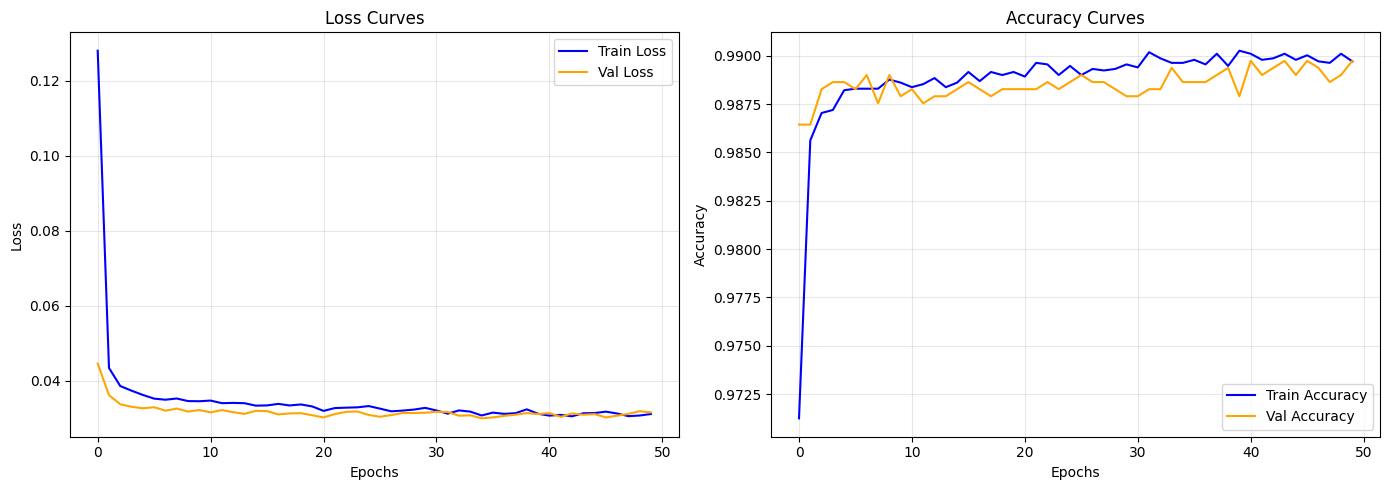

In [69]:


def plot_training_curves(history: Dict[str, List[float]]) -> None:
    """
    Plots the training and validation loss and accuracy curves over epochs.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='orange')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_training_curves(training_history)

In [73]:

def evaluate_test_set(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    criterion: nn.Module, 
    device: torch.device
) -> Tuple[float, float]:
    """
    Evaluates the model on the completely unseen test set.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            running_corrects += (torch.argmax(outputs, 1) == y_batch).sum().item()
            total_samples += X_batch.size(0)
            
    final_loss = running_loss / total_samples
    final_accuracy = running_corrects / total_samples
    
    return final_loss, final_accuracy

# Run the evaluation
test_loss, test_accuracy = evaluate_test_set(model, test_loader, criterion, DEVICE)

print("="*50)
print("FINAL TEST SET RESULTS")
print("="*50)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("="*50)

    

FINAL TEST SET RESULTS
Test Loss:     0.0249
Test Accuracy: 99.19%


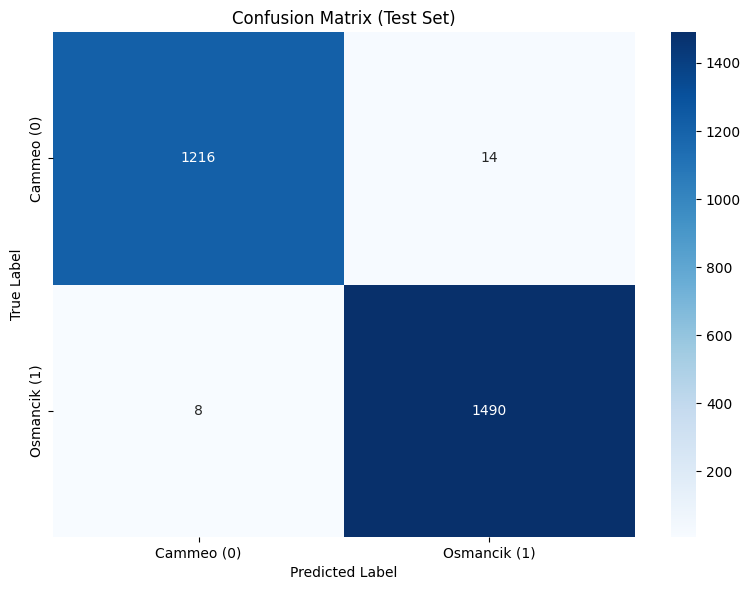

In [71]:

def plot_confusion_matrix(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    device: torch.device,
    class_names: List[str] = ['Cammeo (0)', 'Osmancik (1)']
) -> None:
    """
    Plots a confusion matrix to visualize model errors on the test set.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Execute the confusion matrix plot
plot_confusion_matrix(model, test_loader, DEVICE)